In [2]:
import os
import sys

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

In [3]:
fluorophores = fl.construct_fluorophores(
    name="cy5_dna", distance=6, count=3, shape="square"
)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

irradiance=5
wavelength=640
bleaching=True
energy_transfer=True
reducing_agent="mea"
concentration=100
ph=7.5


In [4]:
transitions = fluorophore_system.load_transitions(
    irradiance=irradiance,
    wavelength=wavelength,
    bleaching=bleaching,
    energy_transfer=energy_transfer,
    dstorm=True,
    dstorm_parameters={'reducing_agent':reducing_agent,
    'concentration':concentration,
    'ph':ph},
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
#transition_set = transition_set.adjust_rates({5:2e4, 4:1e7, 14:1e3, 13:4e4})
transition_set.finalize()

In [5]:
transition_set.transition_df

transition_type  \
Fluorophore                         identity                                           
cy5_dna                             0                      TransitionType.EXCITATION   
                                    1            TransitionType.FLUORESCENT_EMISSION   
                                    2         TransitionType.INTERSYSTEM_CROSSING_ST   
                                    3         TransitionType.INTERSYSTEM_CROSSING_TS   
                                    4                   TransitionType.ISOMERIZATION   
                                    5                      TransitionType.PHOTO_BISO   
                                    6                      TransitionType.THERM_BISO   
                                    7           TransitionType.INTERNAL_CONVERSION_S   
                                    8                      TransitionType.ET_CYCLE_T   
                                    9                      TransitionType.ET_CYCLE_S   
                                    10                    TransitionType.REDUCTION_T   
                                    11                    TransitionType.REDUCTION_S   
                                    12                    TransitionType.OXIDATION_1   
                                    13               TransitionType.PHOTOBLEACHING_1   
D: cy5_dna, A: cy5_dna, dist: 6.0   14                     TransitionType.CIS_FRET_1   
                                    15                     TransitionType.CIS_FRET_2   
                                    16                     TransitionType.OFF_FRET_1   
                                    17                     TransitionType.OFF_FRET_2   
                                    18                           TransitionType.FRET   
                                    19               TransitionType.S_S_ANNIHILATION   
                                    20               TransitionType.S_T_ANNIHILATION   
D: cy5_dna, A: cy5_dna, dist: 8.485 21                     TransitionType.CIS_FRET_1   
                                    22                     TransitionType.CIS_FRET_2   
                                    23                     TransitionType.OFF_FRET_1   
                                    24                     TransitionType.OFF_FRET_2   
                                    25                           TransitionType.FRET   
                                    26               TransitionType.S_S_ANNIHILATION   
                                    27               TransitionType.S_T_ANNIHILATION   

                                             abbreviation  \
Fluorophore                         identity                
cy5_dna                             0                 EXC   
                                    1                 FLU   
                                    2               ISCST   
                                    3               ISCTS   
                                    4                 ISO   
                                    5               PBISO   
                                    6               TBISO   
                                    7                 ICS   
                                    8                 ETT   
                                    9                 ETS   
                                    10               REDT   
                                    11               REDS   
                                    12               OXI1   
                                    13               BLE1   
D: cy5_dna, A: cy5_dna, dist: 6.0   14             CFRET1   
                                    15             CFRET2   
                                    16             OFRET1   
                                    17             OFRET2   
                                    18               FRET   
                                    19                SSA   
                                    20                STA   
D: cy5_dna, A: cy5_dna, d

In [6]:
import sim_data_analysis as sda

In [7]:
memory = 0
threshold = 10
number_of_simulations = 1

fluorophore 0 has reached the Markovian absorbing state SingleState.B
fluorophore 2 has reached the Markovian absorbing state SingleState.B


WARNING for line:             warnings.warn(
 if a fluorophore reaches its individual absorbing state, it has an absolute state and transition frequency of 1, but the lifetime is nan and the state occupation 0. 
WARNING for line:         ax.set_yscale(yscale)
 Data has no positive values, and therefore cannot be log-scaled. 


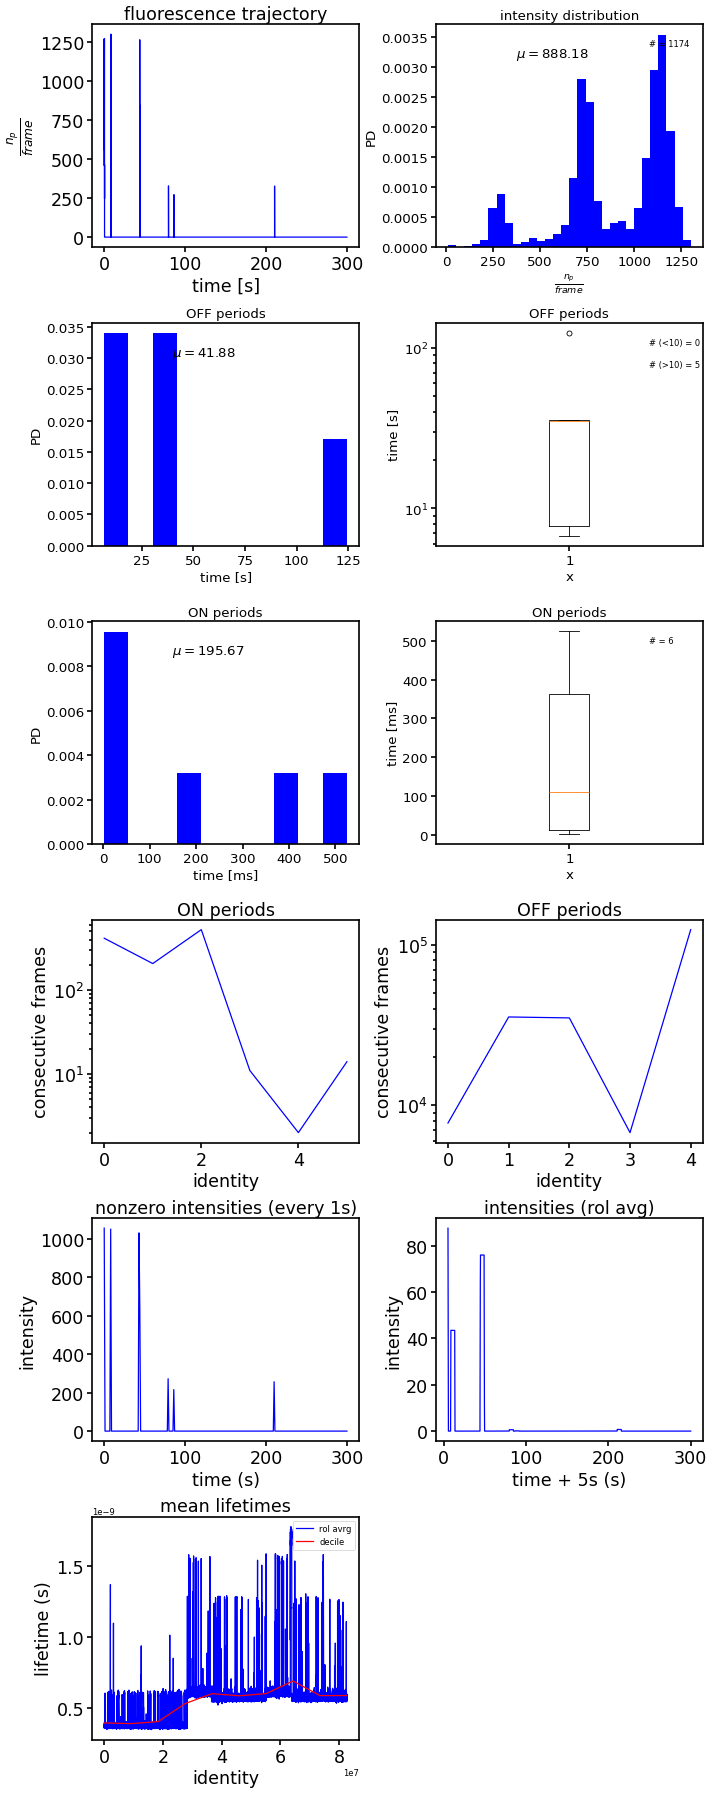

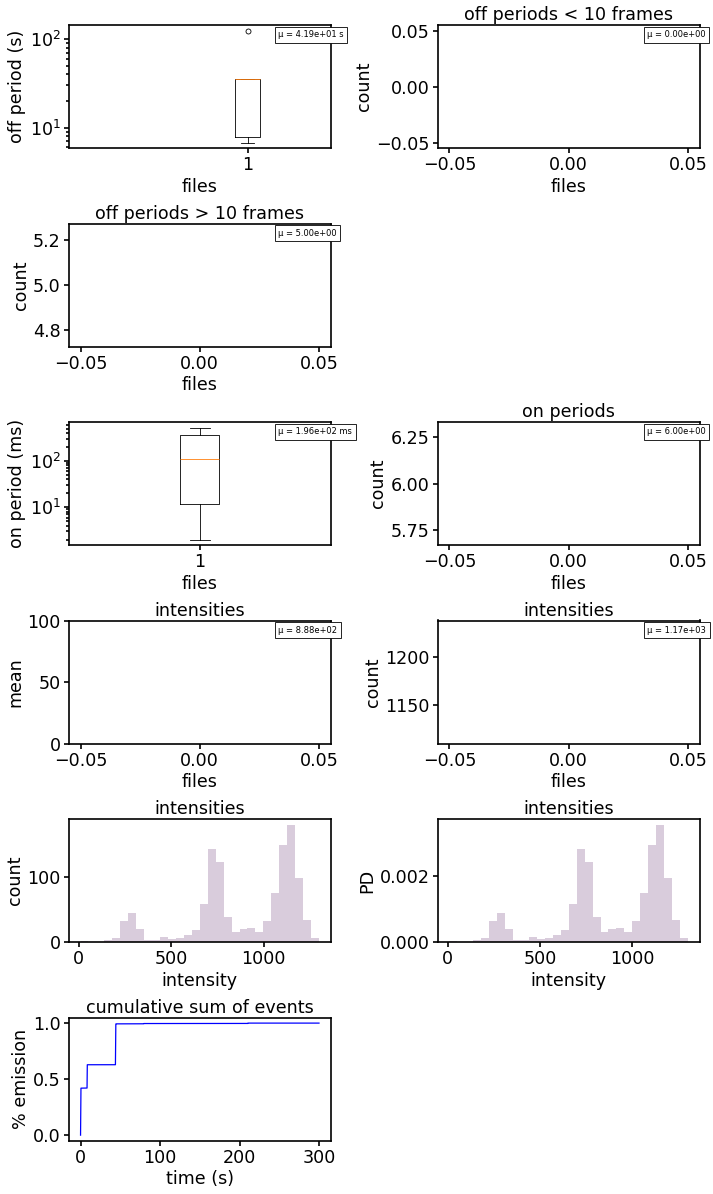

In [8]:
sda.simulate_data(number_of_simulations=number_of_simulations, memory=memory, 
                  threshold=threshold, transition_set=transition_set,
                  long_sim=False, memmap=r'C:\Users\vie43sq\Desktop\memmaps\run_1')

### Photoswitching fingerprint

In [4]:
rng = np.random.default_rng(1)

In [28]:
num_simulations = 300
all_events_summed = pd.Series(np.zeros(300001), np.linspace(0, 300, 300001))
transition_set.finalize()

for i in range(num_simulations):
    simulation = si.Simulation(transition_set)
    simulation.run(size=1e6, seed=rng, end_time=300)
    emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
    emis.extract(simulation)
    photon_collection_rate = fo.calculate_photon_collection_rate(NA=1.45, n1=1.51)
    emis.add_photon_collection_objective(p=photon_collection_rate, seed=rng) 
    emis.add_transmittance(p=0.9, seed=rng)  # mirror 90/100
    emis.add_transmittance(p=0.99, seed=rng) # lens 1
    emis.add_transmittance(p=0.99, seed=rng) # lens 2
    emis.add_quantum_efficiency(p=0.85, seed=rng)
    emis.add_poisson_noise(rate=0.6, seed=rng)
    emis.apply_threshold(threshold=10)
    all_events_summed = all_events_summed + emis.event_time_series.values

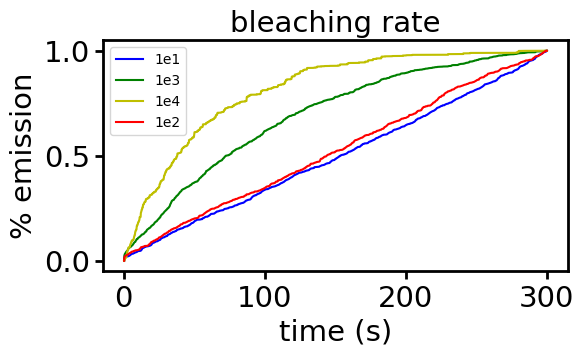

In [38]:
ax = fi.universal_figure(data=[all_events_summed.index[300:], rel_all_events_discard_bl_1e1], 
                        label='1e1')
fi.universal_figure(data=[all_events_summed.index[300:], rel_all_events_discard_bl_1e3],
                    axes=ax[0], color='g', label='1e3')
fi.universal_figure(data=[all_events_summed.index[300:], rel_all_events_discard_bl_1e4],
                    axes=ax[0], color='y', label='1e4')
fi.universal_figure(data=[all_events_summed.index[300:], rel_all_events_discard_bl_1e2], 
                    title='bleaching rate', ylabel='% emission', xlabel='time (s)', 
                    axes=ax[0], color='r', label='1e2', legend=True)
fig = mi.get_figure(ax)
fig.savefig("bl_rate_cum_locs.svg")